In [12]:
# finding
# 1. Y: label df, usually just from 2005 (baseline) or 2006 (12 month)
# 2. X: image data, usually first folder, first .tar.gz contains the KNEE image

In [13]:
import os
REPO_DIR = "/Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck"

ROOT_DIR = os.path.join(REPO_DIR, "data", "OAI", "1243742", "image03", "12m", "1.E.1")

### Remove Partial tar.gz

In [ ]:
# import os
# import tarfile

# def remove_incomplete_tar_gz(root_dir):
#     """
#     Scans root_dir recursively for .tar.gz files and deletes any that are
#     incomplete or corrupted. A tar.gz is considered incomplete if:
#       1. It is empty (0 bytes)
#       2. It cannot be opened as a valid gzip/tar archive (corrupted header)
#       3. It cannot be fully read to the end (truncated mid-stream)

#     Args:
#         root_dir (str): directory to scan recursively

#     Returns:
#         dict: summary counts with keys total, complete, deleted
#     """
#     total_checked = 0
#     total_complete = 0
#     total_deleted  = 0

#     for root, dirs, files in os.walk(root_dir):
#         for file in files:
#             if not file.endswith(".tar.gz"):
#                 continue

#             tar_path = os.path.join(root, file)
#             total_checked += 1
#             reason = None

#             # Check 1: empty file — fastest check, no need to open
#             if os.path.getsize(tar_path) == 0:
#                 reason = "empty file (0 bytes)"

#             # Check 2 & 3: open and walk all members to catch truncation mid-stream
#             if reason is None:
#                 try:
#                     with tarfile.open(tar_path, "r:gz") as tar:
#                         for member in tar:
#                             pass  # force-read every member header to EOF
#                 except tarfile.TruncatedHeaderError:
#                     reason = "truncated header"
#                 except tarfile.ReadError as e:
#                     reason = f"read error: {e}"
#                 except EOFError:
#                     reason = "unexpected EOF (truncated)"
#                 except Exception as e:
#                     reason = f"unexpected error: {e}"

#             if reason:
#                 # Incomplete — delete and log
#                 print(f"[DELETE] {tar_path} — {reason}")
#                 os.remove(tar_path)
#                 total_deleted += 1
#             else:
#                 # Fully intact
#                 total_complete += 1

#     # Final summary
#     print(f"\n{'='*50}")
#     print(f"Total .tar.gz checked : {total_checked}")
#     print(f"Complete              : {total_complete}")
#     print(f"Deleted (incomplete)  : {total_deleted}")
#     print(f"{'='*50}")

#     return {
#         "total":    total_checked,
#         "complete": total_complete,
#         "deleted":  total_deleted,
#     }


# summary = remove_incomplete_tar_gz(ROOT_DIR)


Total .tar.gz checked : 10
Complete              : 10
Deleted (incomplete)  : 0


### Extract all tar.gz

In [15]:
import os
import tarfile

# Counters
total_tar_gz_files = 0
total_already_extracted = 0
total_newly_extracted = 0
total_extraction_errors = 0
total_jpg_1x1 = 0
total_001_files = 0

def extract_tar_if_needed(tar_path):
    global total_tar_gz_files, total_already_extracted, total_newly_extracted
    global total_extraction_errors, total_jpg_1x1, total_001_files

    parent_dir = os.path.dirname(tar_path)
    tar_name = os.path.basename(tar_path)

    if not tar_name.endswith(".tar.gz"):
        return

    base_name = tar_name[:-7]  # e.g. "01653203" from "01653203.tar.gz"
    extract_dir = os.path.join(parent_dir, base_name)
    total_tar_gz_files += 1

    # --- Check for companion _1x1.jpg ---
    jpg_path = os.path.join(parent_dir, f"{base_name}_1x1.jpg")
    if os.path.isfile(jpg_path):
        total_jpg_1x1 += 1

    # --- Check for {number}/001 file inside the extracted dir ---
    file_001_path = os.path.join(extract_dir, "001")
    if os.path.isfile(file_001_path):
        total_001_files += 1

    # --- Skip if already extracted and non-empty ---
    if os.path.isdir(extract_dir) and os.listdir(extract_dir):
        print(f"[SKIP]    Already extracted: {tar_path}")
        total_already_extracted += 1
        return

    # --- Extract ---
    print(f"[EXTRACT] Extracting: {tar_path}")
    try:
        with tarfile.open(tar_path, "r:gz") as tar:
            tar.extractall(path=extract_dir)
        total_newly_extracted += 1
        print(f"[OK]      Done -> {extract_dir}")

        # Re-check for 001 after fresh extraction
        if os.path.isfile(file_001_path):
            total_001_files += 1
            print(f"[INFO]    Found 001 file at: {file_001_path}")

    except Exception as e:
        total_extraction_errors += 1
        print(f"[ERROR]   Failed to extract {tar_path}: {e}")


# --- Walk and process ---
print(f"{'='*60}")
print(f"Scanning ROOT_DIR: {ROOT_DIR}")
print(f"{'='*60}\n")

for root, dirs, files in os.walk(ROOT_DIR):
    for file in files:
        if file.endswith(".tar.gz"):
            tar_path = os.path.join(root, file)
            extract_tar_if_needed(tar_path)

# --- Final summary ---
print(f"\n{'='*60}")
print(f"EXTRACTION SUMMARY")
print(f"{'='*60}")
print(f"  Total .tar.gz files found       : {total_tar_gz_files}")
print(f"  Already extracted  (skipped)    : {total_already_extracted}")
print(f"  Newly extracted    (this run)   : {total_newly_extracted}")
print(f"  Extraction errors               : {total_extraction_errors}")
print(f"  Total extracted    (all time)   : {total_already_extracted + total_newly_extracted}")
print(f"{'='*60}")
print(f"  Companion _1x1.jpg files found  : {total_jpg_1x1}")
print(f"  {{number}}/001 files found         : {total_001_files}")
print(f"{'='*60}")


Scanning ROOT_DIR: /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1

[SKIP]    Already extracted: /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1/9001104/20060720/01674403.tar.gz
[SKIP]    Already extracted: /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1/9000099/20060713/01679604.tar.gz
[SKIP]    Already extracted: /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1/9000099/20060713/01653203.tar.gz
[SKIP]    Already extracted: /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1/9002116/20060804/01693103.tar.gz
[SKIP]    Already extracted: /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1/9003658/20060622/01612004.tar.gz
[SKIP]    Already extracted: /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptB

### Check 001 file

Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 216
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: Computed Radiography Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.21767.172.16.8.165.1152688719.639.0.1.1
(0002, 0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002, 0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.5.3
(0002, 0013) Implementation Version Name         SH: 'OFFIS_DCMTK_353'
(0002, 0016) Source Application Entity Title     AE: 'SYNARC_IMDA'
-------------------------------------------------
(0008, 0000) Group Length                        UL: 458
(0008, 0005) Specific Character Set              CS: 'ISO_IR 100'
(0008, 0016) SOP Class UID                       UI: Computed Radiography Image Storage
(0008, 0018) SOP Instance UID                    UI: 1.3.6.1.4.1.21767.172.1

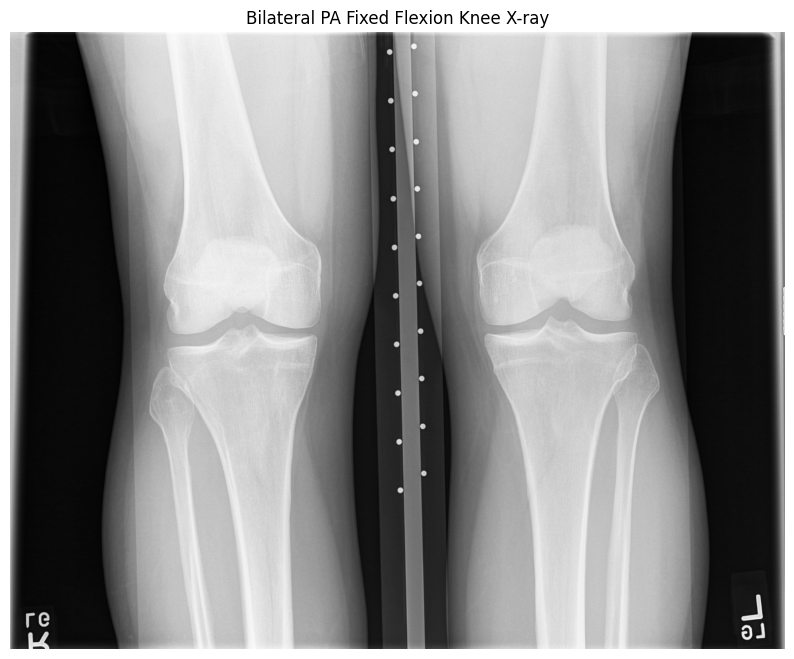

In [16]:
import os
import pydicom

def get_dicom_data(file_path):
    ds = pydicom.dcmread(file_path)
    return ds
    
import matplotlib.pyplot as plt
import pydicom

def plot_dicom_image(file_path):
    # Load DICOM
    ds = pydicom.dcmread(file_path)

    # Access pixel array
    img = ds.pixel_array

    # Normalize for display (0-1)
    img_norm = (img - img.min()) / (img.max() - img.min())

    # Show image
    plt.figure(figsize=(10,10))
    plt.imshow(img_norm, cmap='gray')
    plt.axis('off')
    plt.title("Bilateral PA Fixed Flexion Knee X-ray")
    plt.show()

file_path = ROOT_DIR + "/9003658/20060622/01612004/001"
print(get_dicom_data(file_path=file_path))
plot_dicom_image(file_path=file_path)

In [17]:
ds = get_dicom_data(file_path=file_path)
ds.BodyPartExamined, ds.StudyDescription

('KNEE', 'OAI^XRAY^12 MONTH^KNEE')

### Check how many of them are KNEE

In [18]:
import os
import pydicom
from pydicom.errors import InvalidDicomError
from collections import Counter

knee_paths = []

def find_body_part_stats(root):
    body_part_counter = Counter()
    total_files_count = 0
    no_body_part_count = 0
    invalid_dicom_count = 0

    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            if fname.endswith((".tar.gz", ".jpg")):
                continue

            fpath = os.path.join(dirpath, fname)

            try:
                ds = pydicom.dcmread(fpath, stop_before_pixels=True, force=True)
            except InvalidDicomError:
                invalid_dicom_count += 1
                continue

            total_files_count += 1

            body_part = ds.get((0x0018, 0x0015), None)
            if body_part is None:
                no_body_part_count += 1
                continue

            body_part_counter[str(body_part.value).upper()] += 1

            if str(body_part.value).upper() == "KNEE":
                knee_paths.append(fpath)

    return knee_paths, body_part_counter, total_files_count, no_body_part_count, invalid_dicom_count


knee_paths, body_part_counter, total_files_count, no_body_part_count, invalid_dicom_count = find_body_part_stats(ROOT_DIR)

print(f"{'='*50}")
print(f"Total /001 files scanned       : {total_files_count}")
print(f"Invalid DICOM (skipped)   : {invalid_dicom_count}")
print(f"Missing body part tag     : {no_body_part_count}")
print(f"Files with body part tag  : {sum(body_part_counter.values())}")
print(f"{'='*50}")
print(f"Body part breakdown (descending):")
print(f"{'='*50}")
for body_part, count in body_part_counter.most_common():
    print(f"  {body_part:<30} : {count}")
print(f"{'='*50}")

print(f"Total knee files found    : {len(knee_paths)}")
print(f"Sample knee file paths:")
for kp in knee_paths[:5]:  # show first 5 paths
    print(f"  {kp}")


Total /001 files scanned       : 10
Invalid DICOM (skipped)   : 0
Missing body part tag     : 0
Files with body part tag  : 10
Body part breakdown (descending):
  KNEE                           : 8
  LEG                            : 2
Total knee files found    : 8
Sample knee file paths:
  /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1/9001104/20060720/01674403/001
  /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1/9000099/20060713/01653203/001
  /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1/9002116/20060804/01693103/001
  /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1/9003658/20060622/01612004/001
  /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1/9000622/20060710/01597803/001


### Quantitive Analysis

In [19]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

file_path_clinical_OA_concepts = os.path.join(REPO_DIR, "data", "OAI", "Package_1243743", "oai_kxrsemiquant01.txt")
df_clinical_OA_concepts = pd.read_csv(file_path_clinical_OA_concepts, sep="\t")  # tab-separated
# This removes every row that contains at least one NaN.
df_clinical_OA_concepts = df_clinical_OA_concepts.dropna(how="any")
df_clinical_OA_concepts.head()


/var/folders/_v/v8synrmd28x1bl9_zv9pjk940000gn/T/ipykernel_23986/2466066822.py:6: DtypeWarning: Columns (0,1,2,4,6,8,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clinical_OA_concepts = pd.read_csv(file_path_clinical_OA_concepts, sep="\t")  # tab-separated


,collection_id,oai_kxrsemiquant01_id,dataset_id,subjectkey,src_subject_id,interview_date,interview_age,sex,ageyears,visit,version,readprj,side,xrkl,xrjsl,xrjsm,xrcytl,xrcytm,xrcyfl,xrcyfm,xrostl,xrostm,xrosfl,xrosfm,xrsctm,xrsctl,xrscfm,xrscfl,xrattl,xrattm,xrchl,xrchm,barcode,collection_title
0,collection_id,oai_kxrsemiquant01_id,dataset_id,The NDAR Global Unique Identifier (GUID) for research subject,Subject ID how it's defined in lab/project,Date on which the interview/genetic test/sampling/imaging/biospecimen was completed. MM/DD/YYYY,Age in months at the time of the interview/test/sampling/imaging.,Sex of subject at birth,Age in years,Visit name,Version/code of assessment,Project,Side,Kellgren and Lawrence (grades 0- 4),Joint space narrowing (OARSI grades 0- 3) lateral compartment,Joint space narrowing (OARSI grades 0- 3) medial compartment,Cysts (Grades 0- 1) tibia lateral compartment,Cysts (Grades 0- 1) tibia medial compartment,Cysts (Grades 0- 1) femur lateral compartment,Cysts (Grades 0- 1) femur medial compartment,Osteophytes (OARSI grades 0- 3) tibia lateral compartment,Osteophytes (OARSI grades 0- 3) tibia medial compartment,Osteophytes (OARSI grades 0- 3) femur lateral compartment,Osteophytes (OARSI grades 0- 3) femur medial compartment,Sclerosis (OARSI grades 0- 3) tibia medial compartment,Sclerosis (OARSI grades 0- 3) tibia lateral compartment,Sclerosis (OARSI grades 0- 3) femur medial compartment,Sclerosis (OARSI grades 0- 3) femur lateral compartment,Attrition (OARSI grades 0- 3) tibia lateral compartment,Attrition (OARSI grades 0- 3) tibia medial compartment,Chondrocalcinosis (Grades 0- 1) lateral compartment,Chondrocalcinosis (Grades 0- 1) medial compartment,Barcode of image analyzed,collection_title
1,2343,1,55677,NDAR_INVV5HVXTKF,9000099,07/08/2005,708,M,59,V00,0.8,15,1,2,0,0,0,0,0,0,1,1,2,0,0,0,0,0,0,0,0,0,16600839603,Osteoarthritis Initiative
2,2343,2,55677,NDAR_INVV5HVXTKF,9000099,07/08/2005,708,M,59,V00,0.8,15,2,3,2,0,0,1,0,0,1,0,2,0,0,2,0,2,0,0,0,0,16600839603,Osteoarthritis Initiative
3,2343,3,55677,NDAR_INVJ84F20BN,9000296,09/09/2004,828,M,69,V00,0.8,15,1,2,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,16600175004,Osteoarthritis Initiative
4,2343,4,55677,NDAR_INVJ84F20BN,9000296,09/09/2004,828,M,69,V00,0.8,15,2,3,0,2,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,16600175004,Osteoarthritis Initiative


In [20]:
len(df_clinical_OA_concepts)

26449

In [21]:
import os
from datetime import datetime

def parse_subject_and_date(dicom_path):
    parts = dicom_path.split(os.sep)

    subject_id = parts[-4]          # e.g. '9000099'
    date_yyyymmdd = parts[-3]        # e.g. '20060713'

    interview_date = datetime.strptime(
        date_yyyymmdd, "%Y%m%d"
    ).strftime("%m/%d/%Y")

    return subject_id, interview_date

def filter_valid_knee_paths(path_list, df):
    """
    Returns paths whose (src_subject_id, interview_date)
    exist in df_clinical_OA_concepts.
    """

    # Normalize DF keys once (important for speed + correctness)
    df_keys = set(
        zip(
            df["src_subject_id"].astype(str),
            df["interview_date"]
        )
    )

    valid_paths = []

    for path in path_list:
        try:
            subject_id, interview_date = parse_subject_and_date(path)
        except Exception:
            continue  # malformed path → skip

        if (subject_id, interview_date) in df_keys:
            valid_paths.append(path)

    return valid_paths

valid_paths = filter_valid_knee_paths(
    path_list=knee_paths, # only filter the knee paths, not all dicoms
    df=df_clinical_OA_concepts
)

print(f"Number of knee paths existing in clinical OA concepts df: {len(valid_paths)}")
print("Sample valid knee paths:")
for vp in valid_paths[:5]:  # show first 5 valid paths
    print(f"  {vp}")


Number of knee paths existing in clinical OA concepts df: 4
Sample valid knee paths:
  /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1/9001104/20060720/01674403/001
  /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1/9000099/20060713/01653203/001
  /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1/9002116/20060804/01693103/001
  /Users/yuhaohe/Documents/RA/healthcare_AI_RA/ConceptBottleneck/data/OAI/1243742/image03/12m/1.E.1/9002430/20060601/01580804/001


In [22]:
# # sanity check: ensure that each valid knee path corresponds to a unique (subject_id, interview_date) in the clinical OA concepts df
# # show that for each subject_id + interview_date, only one knee path exists in the filtered list

# seen_combinations = set()
# duplicates = []
# for path in knee_paths:
#     try:
#         subject_id, interview_date = parse_subject_and_date(path)
#     except Exception:
#         continue  # malformed path → skip

#     combo = (subject_id, interview_date)
#     if combo in seen_combinations:
#         duplicates.append(combo)
#     else:
#         seen_combinations.add(combo)

# print(f"Total unique subject + date combinations: {len(seen_combinations)}")
# print(f"Total duplicate combinations: {len(duplicates)}")